In [2]:
import os
from field import Field
import pandas as pd
import numpy as np


In [3]:
dates = "C:\\Users\\gfman\\Documents\\RadiationData" # folder that contains all radiation fields
master = pd.DataFrame()
for date in os.listdir(dates): # iterate through each day of saved data

    files = dates + "/" + date # folder that contains all the fields for a select day

    metadata = pd.read_json(files + "/" + os.listdir(files)[-1]).set_index("FieldID") # read the metadata of the daily files

    mcs = []
    circumferences = []
    areas = []
    spans = []
    coa = []
    for file in os.listdir(files): # iterate over every file from the day
        if "MetaData" in file:
            continue
        filename = files + "/" + file # create file name

        try:
            field = Field(filename) # try to make a Field object from the radiation field
        except:
            continue

        areas.append(field.gantry_total_areas.mean())
        circumferences.append(field.aperature_circumference.mean())
        mcs.append(field.overall_mcs)
        spans.append(field.spans.max())
        coa.append(areas[-1]/circumferences[-1])

    metadata["Area"] = areas
    metadata["Circumference"] = circumferences
    metadata["MCS"] = mcs
    metadata['Span'] = spans
    metadata["CoA"] = coa

    master = pd.concat([master, metadata])
            


# modeling

In [23]:
X = master[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]]
y = master["AD"] < master["ADPass"]


Text(0.5, 1.0, 'Distribution of MU')

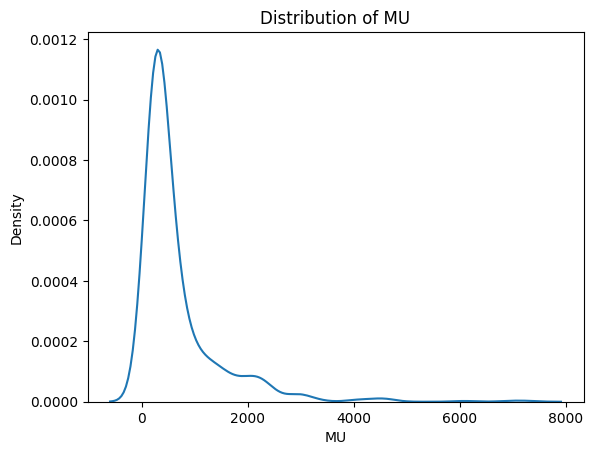

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(X["MU"]) 
plt.title("Distribution of MU")

Text(0.5, 1.0, 'Distribution of Area')

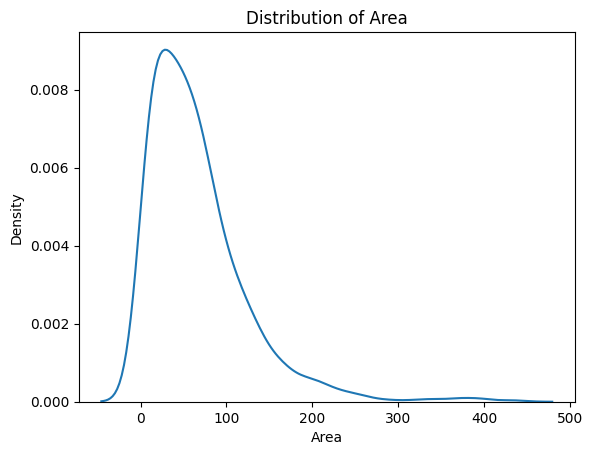

In [29]:
sns.kdeplot(X["Area"]) 
plt.title("Distribution of Area")

Text(0.5, 1.0, 'Distribution of Circumference')

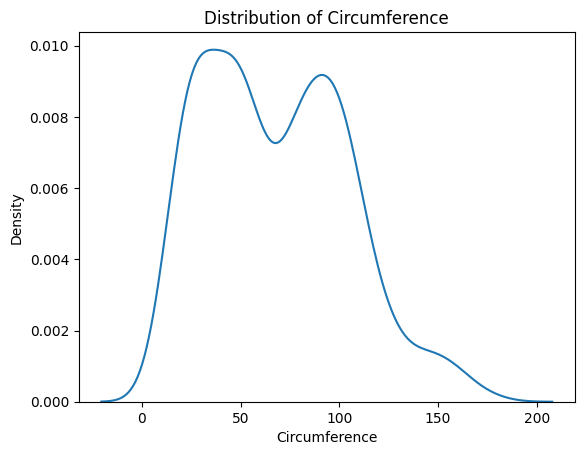

In [30]:
sns.kdeplot(X["Circumference"]) 
plt.title("Distribution of Circumference")

Text(0.5, 1.0, 'Distribution of MCS')

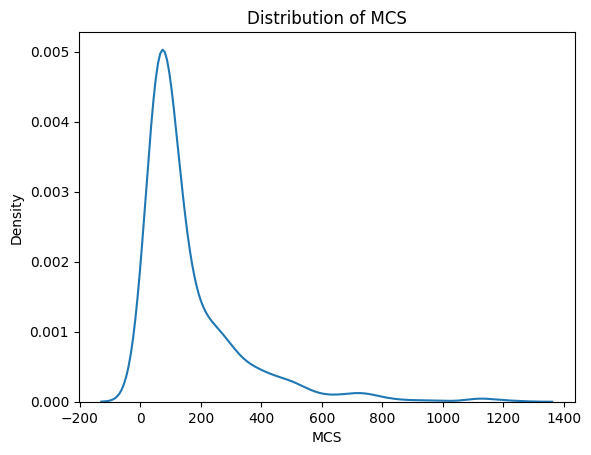

In [31]:
sns.kdeplot(X["MCS"]) 
plt.title("Distribution of MCS")

Text(0.5, 1.0, 'Distribution of Span')

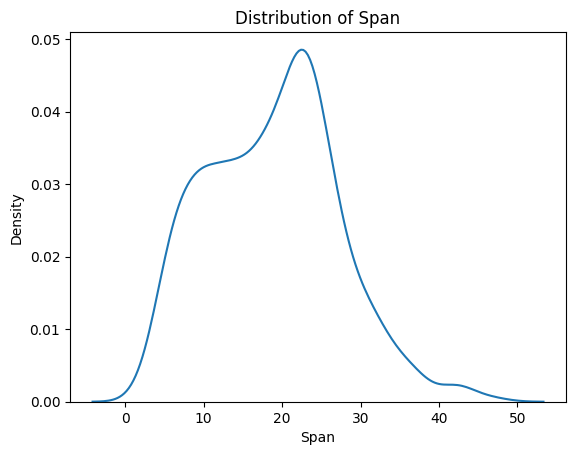

In [32]:
sns.kdeplot(X["Span"]) 
plt.title("Distribution of Span")